In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv(
    "../data/processed/telecom_customers_clean.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,NumServices
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,3
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,3
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [4]:
df.shape

(7043, 22)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'NumServices'],
      dtype='str')

In [6]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "NumServices"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [7]:
X_cluster = df[numeric_features + categorical_features]

In [8]:
X_cluster.shape

(7043, 20)

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [10]:
X_cluster_preprocessed = preprocessor.fit_transform(X_cluster)

In [11]:
X_cluster_preprocessed.shape

(7043, 46)

In [12]:
from sklearn.cluster import KMeans


inertias = []
k_values = range(1, 11)


for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_cluster_preprocessed)
    inertias.append(kmeans.inertia_)

In [13]:
inertias

[94806.74755075961,
 73595.21431956194,
 57926.150189894455,
 53302.38933800341,
 50341.33247102392,
 47871.94908802022,
 45864.09903828414,
 44078.91925664378,
 42727.2392708515,
 41688.31726525679]

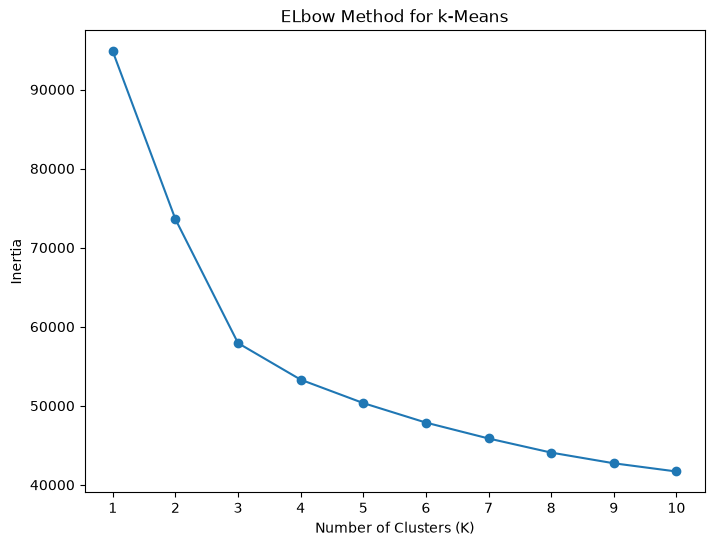

In [14]:
plt.figure(figsize=(8, 6))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("ELbow Method for k-Means")
plt.xticks(k_values)

plt.show()

In [18]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

k_values_silhouette = range(2, 11)

for k in k_values_silhouette:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_cluster_preprocessed)

    score = silhouette_score(
        X_cluster_preprocessed,
        labels
    )

    silhouette_scores.append(score)

In [19]:
silhouette_scores

[0.23993684175593052,
 0.2452259284725098,
 0.23624570712243004,
 0.20169949607536988,
 0.18962483639106498,
 0.19401884828065022,
 0.15616436782771007,
 0.15007935503445388,
 0.1391257363620804]

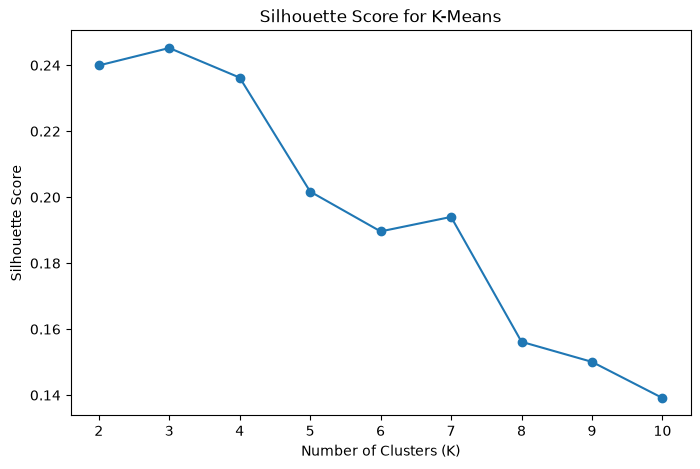

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values_silhouette,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-Means")
plt.xticks(k_values_silhouette)

plt.show()

In [21]:
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(
    X_cluster_preprocessed
)

In [22]:
df['Cluster'] = cluster_labels

In [23]:
df['Cluster'].value_counts().sort_index()

Cluster
0    2337
1    1526
2    3180
Name: count, dtype: int64

In [24]:
df.groupby("Cluster")[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "NumServices"
    ]
].mean()

,tenure,MonthlyCharges,TotalCharges,NumServices
Cluster,,,,
0,55.701326,90.187890,5012.205306,5.655541
1,30.547182,21.079194,662.604784,1.224115
2,16.100943,67.037940,1047.644654,2.704403


In [25]:
pd.crosstab(
    df["Cluster"],
    df["Contract"],
    normalize="index"
) * 100

Contract,Month-to-month,One year,Two year
Cluster,,,
0,25.930680,32.605905,41.463415
1,34.338139,23.853211,41.808650
2,86.320755,10.911950,2.767296


In [27]:
pd.crosstab(
    df["Cluster"],
    df["InternetService"],
    normalize="index"
) * 100

InternetService,DSL,Fiber optic,No
Cluster,,,
0,37.954643,62.045357,0.0
1,0.000000,0.000000,100.0
2,48.238994,51.761006,0.0


In [28]:
pd.crosstab(
    df["Cluster"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Cluster,,
0,84.124947,15.875053
1,92.595020,7.404980
2,56.446541,43.553459


In [29]:
from sklearn.metrics import (
    davies_bouldin_score,
    calinski_harabasz_score
)

In [30]:
db_score = davies_bouldin_score(
    X_cluster_preprocessed,
    cluster_labels
)

ch_score = calinski_harabasz_score(
    X_cluster_preprocessed,
    cluster_labels
)

print("Davies-Bouldin:", db_score)
print("Calinski-Harabasz:", ch_score)

Davies-Bouldin: 1.600602666579875
Calinski-Harabasz: 2241.1242985192125


In [31]:
from sklearn.cluster import AgglomerativeClustering

In [32]:
agg_model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

agg_labels = agg_model.fit_predict(
    X_cluster_preprocessed
)

In [33]:
pd.Series(agg_labels).value_counts().sort_index()

0    4475
1    1526
2    1042
Name: count, dtype: int64

In [36]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

agg_silhouette = silhouette_score(
    X_cluster_preprocessed,
    agg_labels
)

agg_db = davies_bouldin_score(
    X_cluster_preprocessed,
    agg_labels
)

agg_ch = calinski_harabasz_score(
    X_cluster_preprocessed,
    agg_labels
)

print("Silhouette:", agg_silhouette)
print("Davies-Bouldin:", agg_db)
print("Calinski-Harabasz:", agg_ch)

Silhouette: 0.1909223324735992
Davies-Bouldin: 1.6248778642357553
Calinski-Harabasz: 1683.107207160616


In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X_cluster_preprocessed
)

In [38]:
X_pca.shape

(7043, 2)

In [39]:
pca.explained_variance_ratio_

array([0.31230737, 0.16981711])

In [40]:
pca.explained_variance_ratio_.sum()

np.float64(0.4821244849103642)

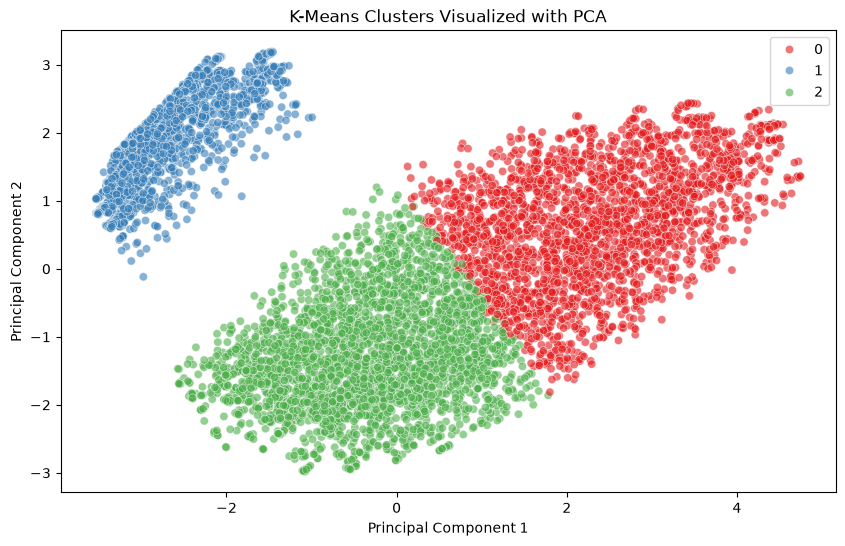

In [41]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_labels,
    palette="Set1",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Visualized with PCA")

plt.show()